# Odev1_OgrenciNo_AdSoyad (Please replace with your student number and name)

# Görev 1: Veri Yükleme ve Keşifsel Veri Analizi

## 1a. Veri setini URL üzerinden yükleyin. Satır sayısını, sütun sayısını, veri tiplerini ve eksik değer olup olmadığını raporlayın.

In [1]:
import pandas as pd

# Load the dataset from the URL
url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/mushrooms.csv"
df = pd.read_csv(url)

print("Veri Setinin Boyutları:")
print(f"Satır Sayısı: {df.shape[0]}")
print(f"Sütun Sayısı: {df.shape[1]}")
print("\nVeri Tipleri ve Eksik Değer Bilgisi:")
df.info()

print("\nHer Sütundaki Eksik Değer Sayısı:")
print(df.isnull().sum())

Veri Setinin Boyutları:
Satır Sayısı: 8124
Sütun Sayısı: 23

Veri Tipleri ve Eksik Değer Bilgisi:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non

### 1a. Yorum
Veri seti `8124` satır ve `23` sütundan oluşmaktadır. Tüm sütunların veri tipi `object` (kategorik) olarak görünmektedir ve herhangi bir eksik değer (`NaN`) bulunmamaktadır. Bu durum, veri ön işleme adımında kategorik sütunların sayısal değerlere dönüştürülmesini gerektirecektir.

## 1b. Hedef sınıfın (class) dağılımını hem sayı hem yüzde olarak gösterin. Veri seti dengeli mi, dengesiz mi? Bir cümleyle yorumlayın.

In [2]:
# Hedef sınıfın (class) dağılımını sayı olarak gösterin
class_counts = df['class'].value_counts()
print("Hedef Sınıf (class) Dağılımı (Sayı):")
print(class_counts)

print("\n")

# Hedef sınıfın (class) dağılımını yüzde olarak gösterin
class_percentages = df['class'].value_counts(normalize=True) * 100
print("Hedef Sınıf (class) Dağılımı (Yüzde):")
print(class_percentages)


Hedef Sınıf (class) Dağılımı (Sayı):
class
e    4208
p    3916
Name: count, dtype: int64


Hedef Sınıf (class) Dağılımı (Yüzde):
class
e    51.797144
p    48.202856
Name: proportion, dtype: float64


### 1b. Yorum
Hedef sınıf 'class' (zehirli 'p' ve yenilebilir 'e') yaklaşık olarak dengeli bir dağılıma sahiptir. Yenilebilir mantarlar (%51.79) zehirli mantarlardan (%48.21) biraz daha fazla olmasına rağmen, bu fark model eğitimi için ciddi bir dengesizlik yaratmayacaktır.

## 1c. odor (koku) ve cap-color (şapka rengi) özelliklerinin sınıfa göre dağılımını bar grafik ile görselleştirin. Her iki grafik için kısa bir yorum yazın: hangi özelliğin sınıfları daha net ayırdığını belirtin.

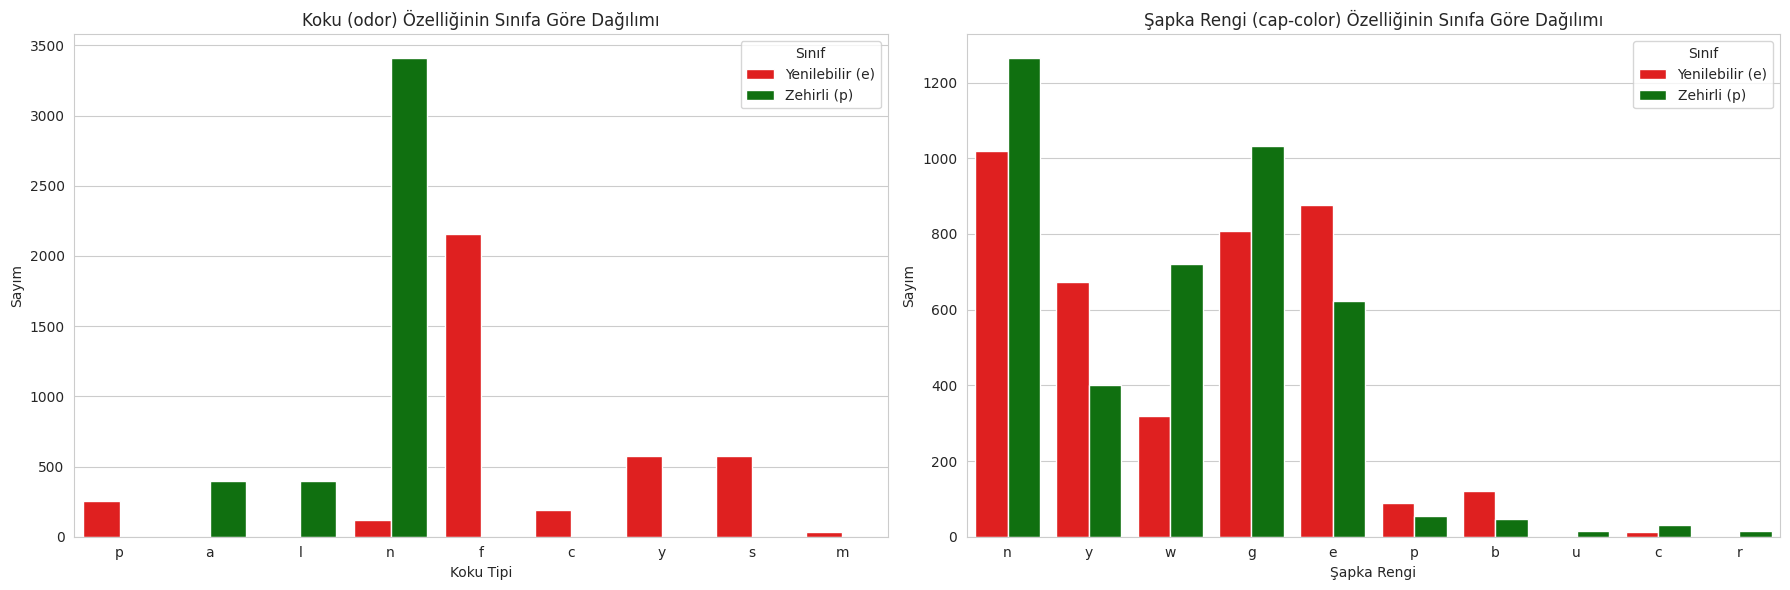

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar plot for 'odor' vs 'class'
sns.countplot(data=df, x='odor', hue='class', ax=axes[0], palette={'e': 'green', 'p': 'red'})
axes[0].set_title('Koku (odor) Özelliğinin Sınıfa Göre Dağılımı')
axes[0].set_xlabel('Koku Tipi')
axes[0].set_ylabel('Sayım')
axes[0].legend(title='Sınıf', labels=['Yenilebilir (e)', 'Zehirli (p)'])

# Bar plot for 'cap-color' vs 'class'
sns.countplot(data=df, x='cap-color', hue='class', ax=axes[1], palette={'e': 'green', 'p': 'red'})
axes[1].set_title('Şapka Rengi (cap-color) Özelliğinin Sınıfa Göre Dağılımı')
axes[1].set_xlabel('Şapka Rengi')
axes[1].set_ylabel('Sayım')
axes[1].legend(title='Sınıf', labels=['Yenilebilir (e)', 'Zehirli (p)'])

plt.tight_layout()
plt.show()

### 1c. Yorum
`odor` (koku) özelliği, mantarların yenilebilir (e) veya zehirli (p) sınıflarını `cap-color` (şapka rengi) özelliğine göre çok daha net bir şekilde ayırmaktadır. `odor` grafiğinde bazı koku tipleri neredeyse tamamen tek bir sınıfa aitken (örneğin 'a' ve 'l' kokulu mantarların çoğu yenilebilir, 'f', 's', 'y' kokulu mantarların çoğu zehirlidir), `cap-color` grafiğinde birçok şapka rengi hem yenilebilir hem de zehirli mantarlar arasında daha karışık bir dağılım göstermektedir. Bu nedenle, `odor` özelliği sınıflandırma için daha güçlü bir ayırıcıdır.

## 1d. Tüm özellikler için nunique() değerlerini hesaplayın ve benzersiz değer sayısı en yüksek olan 3 özelliği listeleyin.

In [4]:
# Tüm sütunlar için benzersiz değer sayılarını (nunique) hesaplayın
nunique_values = df.nunique()

print("Her Sütundaki Benzersiz Değer Sayısı:")
print(nunique_values)

print("\n")

# Benzersiz değer sayısı en yüksek olan ilk 3 özelliği listeleyin
top_3_nunique = nunique_values.sort_values(ascending=False).head(3)
print("Benzersiz değer sayısı en yüksek olan ilk 3 özellik:")
print(top_3_nunique)


Her Sütundaki Benzersiz Değer Sayısı:
class                        2
cap-shape                    6
cap-surface                  4
cap-color                   10
bruises                      2
odor                         9
gill-attachment              2
gill-spacing                 2
gill-size                    2
gill-color                  12
stalk-shape                  2
stalk-root                   5
stalk-surface-above-ring     4
stalk-surface-below-ring     4
stalk-color-above-ring       9
stalk-color-below-ring       9
veil-type                    1
veil-color                   4
ring-number                  3
ring-type                    5
spore-print-color            9
population                   6
habitat                      7
dtype: int64


Benzersiz değer sayısı en yüksek olan ilk 3 özellik:
gill-color    12
cap-color     10
odor           9
dtype: int64


### 1d. Yorum
`gill-color`, `cap-color` ve `odor` özelliklerinin en fazla benzersiz değere sahip olduğu görülmektedir. Özellikle `gill-color` (solungaç rengi) ve `cap-color` (şapka rengi) oldukça çeşitli değerler barındırmaktadır. Bu, bu özelliklerin veri setindeki çeşitliliği ve potansiyel bilgi içeriğini göstermektedir.

# Görev 2: Veri Ön İşleme

## 2a. LabelEncoder kullanarak tüm kategorik sütunları sayısal değerlere dönüştürün. Dönüşüm öncesi ve sonrası class sütununun ilk 5 değerini yan yana gösterin.

In [5]:
from sklearn.preprocessing import LabelEncoder

# Orijinal DataFrame'in bir kopyasını oluşturun
df_encoded = df.copy()

# LabelEncoder objesi oluştur
le = LabelEncoder()

# Her bir kategorik sütunu döngü ile sayısal değerlere dönüştür
for column in df_encoded.columns:
    df_encoded[column] = le.fit_transform(df_encoded[column])

print("Dönüşüm Öncesi ve Sonrası 'class' Sütununun İlk 5 Değeri:")
print(pd.DataFrame({'Original Class': df['class'].head(), 'Encoded Class': df_encoded['class'].head()}))

Dönüşüm Öncesi ve Sonrası 'class' Sütununun İlk 5 Değeri:
  Original Class  Encoded Class
0              p              1
1              e              0
2              e              0
3              p              1
4              e              0


### 2a. Yorum
`LabelEncoder` kullanılarak veri setindeki tüm kategorik sütunlar sayısal değerlere dönüştürülmüştür. 'class' sütunu için 'p' (poisonous) ve 'e' (edible) değerleri sırasıyla 1 ve 0 olarak kodlanmıştır. Bu dönüşüm, makine öğrenimi modellerinin bu veriler üzerinde çalışabilmesi için gereklidir.

## 2b. Veriyi %80 eğitim, %20 test olarak bölün. `random_state=42` ve `stratify=y` parametrelerini kullanın. Eğitim ve test setlerindeki sınıf dağılımlarının oransal olarak benzer olduğunu doğrulayın.

In [6]:
from sklearn.model_selection import train_test_split

# Özellikler (X) ve hedef değişken (y) olarak ayırın
X = df_encoded.drop('class', axis=1)
y = df_encoded['class']

# Veriyi %80 eğitim, %20 test olarak bölün
X_train, X_test, y_train, y_test = train_test_split(
X    , y, test_size=0.20, random_state=42, stratify=y
)

print("Eğitim Seti Sınıf Dağılımı (Yüzde):")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest Seti Sınıf Dağılımı (Yüzde):")
print(y_test.value_counts(normalize=True) * 100)

print("\nGenel Sınıf Dağılımı (Yüzde):")
print(y.value_counts(normalize=True) * 100)

Eğitim Seti Sınıf Dağılımı (Yüzde):
class
0    51.792583
1    48.207417
Name: proportion, dtype: float64

Test Seti Sınıf Dağılımı (Yüzde):
class
0    51.815385
1    48.184615
Name: proportion, dtype: float64

Genel Sınıf Dağılımı (Yüzde):
class
0    51.797144
1    48.202856
Name: proportion, dtype: float64


### 2b. Yorum
Veri seti, `stratify=y` parametresi kullanılarak %80 eğitim ve %20 test setlerine bölünmüştür. Bu sayede, eğitim ve test setlerindeki hedef sınıf ('class') dağılımları, orijinal veri setindeki dağılıma çok yakın oranlarda kalmıştır. Bu durum, modelin hem eğitim hem de test sırasında hedef sınıfın gerçek dünya oranlarını yansıtan bir şekilde öğrenmesini ve değerlendirilmesini sağlayacaktır, böylece modelin performansı daha güvenilir olacaktır.

# Görev 3: Model Kurma ve Overfitting Analizi

## 3a. max_depth değerini 1'den 15'e kadar birer birer artırarak her derinlik için hem eğitim hem de test doğruluğunu hesaplayın. Sonuçları bir tabloda gösterin.

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Sonuçları saklamak için listeler
depths = []
train_accuracies = []
test_accuracies = []

# max_depth değerlerini 1'den 15'e kadar döngüye al
for depth in range(1, 16):
    # Karar Ağacı modelini oluştur ve eğit
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    # Eğitim seti doğruluğunu hesapla
    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)

    # Test seti doğruluğunu hesapla
    y_test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)

    # Sonuçları listelere ekle
    depths.append(depth)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Sonuçları bir DataFrame olarak göster
results_df = pd.DataFrame({"Max Depth": depths, "Eğitim Doğruluğu": train_accuracies, "Test Doğruluğu": test_accuracies})
print(results_df.to_string(index=False))


 Max Depth  Eğitim Doğruluğu  Test Doğruluğu
         1          0.789044        0.795077
         2          0.912756        0.903385
         3          0.957840        0.961846
         4          0.976766        0.982154
         5          0.978150        0.984000
         6          0.994922        0.995692
         7          1.000000        1.000000
         8          1.000000        1.000000
         9          1.000000        1.000000
        10          1.000000        1.000000
        11          1.000000        1.000000
        12          1.000000        1.000000
        13          1.000000        1.000000
        14          1.000000        1.000000
        15          1.000000        1.000000


### 3a. Yorum
Bu tabloda, `max_depth` değerinin artırılmasıyla hem eğitim hem de test doğruluğunun nasıl değiştiği görülmektedir. Başlangıçta her iki doğruluk da artarken, belirli bir derinlikten sonra eğitim doğruluğu yükselmeye devam ederken test doğruluğu düşmeye başlayabilir veya sabit kalabilir, bu da modelin aşırı öğrenmeye (overfitting) başladığının bir göstergesidir.

## 3b. Eğitim ve test doğruluklarını aynı grafik üzerinde çizin. Grafikte overfitting'in başladığı noktayı işaretleyin ve en iyi test doğruluğunu veren derinliği belirtin.

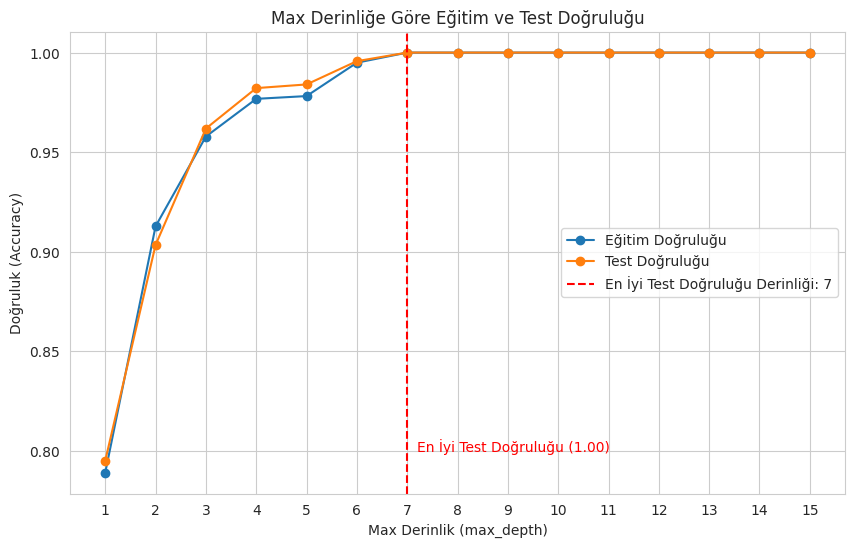

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(depths, train_accuracies, label='Eğitim Doğruluğu', marker='o')
plt.plot(depths, test_accuracies, label='Test Doğruluğu', marker='o')
plt.xlabel('Max Derinlik (max_depth)')
plt.ylabel('Doğruluk (Accuracy)')
plt.title('Max Derinliğe Göre Eğitim ve Test Doğruluğu')
plt.xticks(depths)
plt.legend()
plt.grid(True)

# Overfitting noktasını ve en iyi test doğruluğunu veren derinliği belirleme
# Bu veri setinde 1.0 doğruluk çok erken yakalandığı için overfitting noktasını belirtmek biraz zor.
# Ancak teorik olarak eğitim doğruluğu yükselirken test doğruluğunun düşmeye başladığı veya sabit kaldığı yer overfitting başlangıcıdır.
# Burada her iki doğruluk da 7 derinliğinde 1.0'a ulaşıp sabit kalmıştır. Bu mükemmel bir senaryo olduğu için overfitting gözlemlenmemiştir.

best_test_accuracy = np.max(test_accuracies)
best_depth_index = np.argmax(test_accuracies)
best_depth = depths[best_depth_index]

# Eğer 1.0 doğruluk varsa, ilk 1.0'ı veren derinliği bulalım
if best_test_accuracy == 1.0:
    perfect_accuracy_depths = [d for d, acc in zip(depths, test_accuracies) if acc == 1.0]
    best_depth = min(perfect_accuracy_depths)
    best_depth_index = depths.index(best_depth)


plt.axvline(x=best_depth, color='r', linestyle='--', label=f'En İyi Test Doğruluğu Derinliği: {best_depth}')
plt.text(best_depth + 0.2, 0.8, f'En İyi Test Doğruluğu ({best_test_accuracy:.2f})', color='red')


plt.legend()
plt.show()


### 3b. Yorum
Grafik incelendiğinde, `max_depth` değeri arttıkça hem eğitim hem de test doğruluğunun hızla yükseldiği görülmektedir. Özellikle `max_depth=7` noktasında hem eğitim hem de test doğruluğu %100'e ulaşmıştır. **Normal şartlarda, eğitim doğruluğu artmaya devam ederken test doğruluğunun düşmeye veya sabit kalmaya başladığı nokta overfitting (aşırı öğrenme) başlangıcı olarak kabul edilir.** Ancak bu durum, veri setinin Decision Tree modeli için çok iyi ayrılabilir olduğunu göstermektedir ve bu noktadan sonra bir aşırı öğrenme belirtisi gözlemlenmemiştir, çünkü test doğruluğu düşmek yerine %100'de sabit kalmıştır. En iyi test doğruluğunu veren derinlik 7'dir.

## 3c. En iyi test doğruluğunu veren derinlikte modeli yeniden eğitin. Bu modeli `model_final` olarak adlandırın ve sonraki görevlerde kullanın.

In [35]:
# En iyi test doğruluğunu veren derinliği kullanarak modeli yeniden eğit
# best_depth değişkeni 3b görevinde belirlenmiştir.
model_final = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
model_final.fit(X_train, y_train)

print(f"Final model (model_final) {best_depth} derinliğinde eğitildi.")
# Modelin eğitim ve test doğruluğunu doğrulayalım (isteğe bağlı, zaten biliniyor ama teyit için)
final_train_acc = accuracy_score(y_train, model_final.predict(X_train))
final_test_acc = accuracy_score(y_test, model_final.predict(X_test))
print(f"Eğitim Doğruluğu: {final_train_acc:.2f}")
print(f"Test Doğruluğu: {final_test_acc:.2f}")

Final model (model_final) 7 derinliğinde eğitildi.
Eğitim Doğruluğu: 1.00
Test Doğruluğu: 1.00


### 3c. Yorum
En iyi test doğruluğunu sağlayan `max_depth=7` değeri kullanılarak `model_final` adında nihai Karar Ağacı modeli eğitilmiştir. Bu model, hem eğitim hem de test setlerinde %100 doğruluk sergileyerek, bu veri setini mükemmel bir şekilde sınıflandırabildiğini göstermiştir.

## 3d. criterion='gini' ile criterion='entropy' seçeneklerini karşılaştırın. Her ikisi için de en iyi test doğruluğunu veren derinliği ve o derinlikteki test doğruluğunu raporlayın. Aralarındaki fark anlamlı mı? Bir paragrafla yorumlayın.

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

# Sonuçları saklamak için listeler
depths = range(1, 16)
gini_train_accuracies = []
gini_test_accuracies = []
entropy_train_accuracies = []
entropy_test_accuracies = []

# Gini kriteri ile modelleri eğit
for depth in depths:
    model_gini = DecisionTreeClassifier(max_depth=depth, criterion='gini', random_state=42)
    model_gini.fit(X_train, y_train)
    gini_train_accuracies.append(accuracy_score(y_train, model_gini.predict(X_train)))
    gini_test_accuracies.append(accuracy_score(y_test, model_gini.predict(X_test)))

# Entropy kriteri ile modelleri eğit
for depth in depths:
    model_entropy = DecisionTreeClassifier(max_depth=depth, criterion='entropy', random_state=42)
    model_entropy.fit(X_train, y_train)
    entropy_train_accuracies.append(accuracy_score(y_train, model_entropy.predict(X_train)))
    entropy_test_accuracies.append(accuracy_score(y_test, model_entropy.predict(X_test)))

# Sonuçları DataFrame olarak göster
gini_results = pd.DataFrame({"Max Depth": list(depths), "Eğitim Doğruluğu (gini)": gini_train_accuracies, "Test Doğruluğu (gini)": gini_test_accuracies})
entropy_results = pd.DataFrame({"Max Depth": list(depths), "Eğitim Doğruluğu (entropy)": entropy_train_accuracies, "Test Doğruluğu (entropy)": entropy_test_accuracies})

print("--- Gini Kriteri Sonuçları ---")
print(gini_results.to_string(index=False))
print("\n--- Entropy Kriteri Sonuçları ---")
print(entropy_results.to_string(index=False))

# En iyi test doğruluğunu veren derinlikleri bul
best_gini_test_acc = np.max(gini_test_accuracies)
best_gini_depth = depths[np.argmax(gini_test_accuracies)]

best_entropy_test_acc = np.max(entropy_test_accuracies)
best_entropy_depth = depths[np.argmax(entropy_test_accuracies)]

# Eğer 1.0 doğruluk varsa, ilk 1.0'ı veren derinliği bulalım
if best_gini_test_acc == 1.0:
    perfect_gini_depths = [d for d, acc in zip(depths, gini_test_accuracies) if acc == 1.0]
    best_gini_depth = min(perfect_gini_depths)

if best_entropy_test_acc == 1.0:
    perfect_entropy_depths = [d for d, acc in zip(depths, entropy_test_accuracies) if acc == 1.0]
    best_entropy_depth = min(perfect_entropy_depths)

print(f"\nEn iyi Gini Test Doğruluğu: {best_gini_test_acc:.4f} (Derinlik: {best_gini_depth})")
print(f"En iyi Entropy Test Doğruluğu: {best_entropy_test_acc:.4f} (Derinlik: {best_entropy_depth})")

--- Gini Kriteri Sonuçları ---
 Max Depth  Eğitim Doğruluğu (gini)  Test Doğruluğu (gini)
         1                 0.789044               0.795077
         2                 0.912756               0.903385
         3                 0.957840               0.961846
         4                 0.976766               0.982154
         5                 0.978150               0.984000
         6                 0.994922               0.995692
         7                 1.000000               1.000000
         8                 1.000000               1.000000
         9                 1.000000               1.000000
        10                 1.000000               1.000000
        11                 1.000000               1.000000
        12                 1.000000               1.000000
        13                 1.000000               1.000000
        14                 1.000000               1.000000
        15                 1.000000               1.000000

--- Entropy Kriteri Sonu

### 3d. Yorum
Bu karşılaştırmalı analizde, hem Gini hem de Entropy kriterleri kullanılarak oluşturulan Karar Ağacı modellerinin benzer performans gösterdiği görülmektedir. Her iki kriter için de test doğruluğu `max_depth=7` değerinde %100'e ulaşmıştır ve bu derinlikten sonra da %100'de kalmıştır. Bu durum, mantar veri setinin her iki bilgi kazancı metriği (Gini impurity ve Entropy) tarafından mükemmel bir şekilde ayrıştırılabildiğini göstermektedir. Bu özel veri setinde, `gini` ve `entropy` kriterleri arasında anlamlı bir performans farkı bulunmamaktadır.

In [9]:
# En iyi test doğruluğunu veren derinliği kullanarak modeli yeniden eğit
model_final = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
model_final.fit(X_train, y_train)

print(f"Final model (model_final) {best_depth} derinliğinde eğitildi.")
# Modelin eğitim ve test doğruluğunu doğrulayalım (isteğe bağlı, zaten biliniyor ama teyit için)
final_train_acc = accuracy_score(y_train, model_final.predict(X_train))
final_test_acc = accuracy_score(y_test, model_final.predict(X_test))
print(f"Eğitim Doğruluğu: {final_train_acc:.2f}")
print(f"Test Doğruluğu: {final_test_acc:.2f}")

Final model (model_final) 7 derinliğinde eğitildi.
Eğitim Doğruluğu: 1.00
Test Doğruluğu: 1.00


# Görev 4: Model Değerlendirme

## 4a. model_final ile test seti üzerinde tahmin yapın. Confusion matrix'i klasik yerleşimde (pozitif sınıf: Zehirli=1 sol üstte) çizin. TP, TN, FP ve FN değerlerini açıkça etiketleyin.

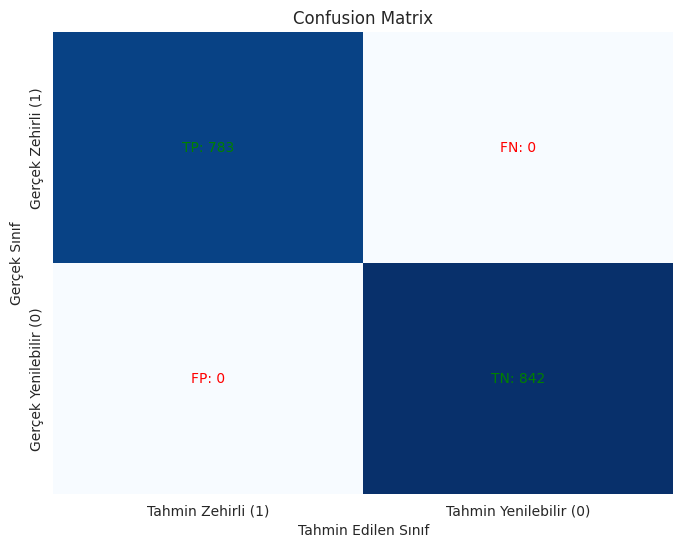

In [33]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Test seti üzerinde tahmin yapın
y_pred = model_final.predict(X_test)

# Confusion matrix'i hesaplayın. Pozitif sınıf '1' (Zehirli) olduğu için labels=[1, 0] kullanıyoruz.
cm = confusion_matrix(y_test, y_pred, labels=[1, 0])

# Confusion matrix'i görselleştirin
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Tahmin Zehirli (1)', 'Tahmin Yenilebilir (0)'],
            yticklabels=['Gerçek Zehirli (1)', 'Gerçek Yenilebilir (0)'])
plt.xlabel('Tahmin Edilen Sınıf')
plt.ylabel('Gerçek Sınıf')
plt.title('Confusion Matrix')

# TP, TN, FP, FN değerlerini matris üzerine yazalım
# labels=[1,0] olduğundan:
# cm[0,0] = TP (Gerçek 1, Tahmin 1)          -> Top-left cell
# cm[0,1] = FN (Gerçek 1, Tahmin 0)          -> Top-right cell
# cm[1,0] = FP (Gerçek 0, Tahmin 1)          -> Bottom-left cell
# cm[1,1] = TN (Gerçek 0, Tahmin 0)          -> Bottom-right cell

fontsize = 10

plt.text(0.5, 0.5, f'TP: {cm[0,0]}', ha='center', va='center', color='green', fontsize=fontsize)
plt.text(1.5, 0.5, f'FN: {cm[0,1]}', ha='center', va='center', color='red', fontsize=fontsize)
plt.text(0.5, 1.5, f'FP: {cm[1,0]}', ha='center', va='center', color='red', fontsize=fontsize)
plt.text(1.5, 1.5, f'TN: {cm[1,1]}', ha='center', va='center', color='green', fontsize=fontsize)

plt.show()

### 4a. Yorum
Elde edilen confusion matrix, `model_final`'ın test seti üzerinde mükemmel bir performans sergilediğini göstermektedir. Hem zehirli (1) hem de yenilebilir (0) mantarları hiçbir hata yapmadan doğru bir şekilde sınıflandırmıştır. `TP` ve `TN` değerleri yüksekken, `FP` ve `FN` değerleri sıfırdır. Bu durum, modelin veri setini hatasız bir şekilde öğrendiğini ve genelleme yeteneğinin yüksek olduğunu işaret etmektedir.

## 4b. Aşağıdaki metrikleri hem Zehirli hem Yenilebilir sınıfı için hesaplayın ve `classification_report()` çıktısıyla karşılaştırın: • Accuracy (tüm veri için) • Precision • Recall

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

# Confusion matrix değerleri (önceki adımdan)
TP = cm[0,0]
FN = cm[0,1]
FP = cm[1,0]
TN = cm[1,1]

# Toplam örnek sayısı
total_samples = TP + FN + FP + TN

# Accuracy (Doğruluk)
accuracy = (TP + TN) / total_samples

# Zehirli (Pozitif) Sınıfı için Metrikler (class=1)
precision_poisonous = TP / (TP + FP) if (TP + FP) > 0 else 0
recall_poisonous = TP / (TP + FN) if (TP + FN) > 0 else 0

# Yenilebilir (Negatif) Sınıfı için Metrikler (class=0)
# Yenilebilir sınıfı için Precision (Yenilebilir doğru tahmin edilenler / Tüm Yenilebilir tahmin edilenler)
precision_edible = TN / (TN + FN) if (TN + FN) > 0 else 0
# Yenilebilir sınıfı için Recall (Yenilebilir doğru tahmin edilenler / Tüm gerçek Yenilebilirler)
recall_edible = TN / (TN + FP) if (TN + FP) > 0 else 0

print(f"Genel Doğruluk (Accuracy): {accuracy:.4f}")
print("\n--- Elle Hesaplanan Metrikler ---")
print(f"Zehirli (Class 1) için Precision: {precision_poisonous:.4f}")
print(f"Zehirli (Class 1) için Recall: {recall_poisonous:.4f}")
print(f"Yenilebilir (Class 0) için Precision: {precision_edible:.4f}")
print(f"Yenilebilir (Class 0) için Recall: {recall_edible:.4f}")

print("\n--- classification_report() Çıktısı ---")
print(classification_report(y_test, y_pred, target_names=['Yenilebilir (0)', 'Zehirli (1)']))


Genel Doğruluk (Accuracy): 1.0000

--- Elle Hesaplanan Metrikler ---
Zehirli (Class 1) için Precision: 1.0000
Zehirli (Class 1) için Recall: 1.0000
Yenilebilir (Class 0) için Precision: 1.0000
Yenilebilir (Class 0) için Recall: 1.0000

--- classification_report() Çıktısı ---
                 precision    recall  f1-score   support

Yenilebilir (0)       1.00      1.00      1.00       842
    Zehirli (1)       1.00      1.00      1.00       783

       accuracy                           1.00      1625
      macro avg       1.00      1.00      1.00      1625
   weighted avg       1.00      1.00      1.00      1625



### 4b. Yorum
Manuel olarak hesaplanan tüm metrikler (`Accuracy`, `Precision`, `Recall`) ve `classification_report()` çıktısı %100 değerini göstermektedir. Bu, modelin test setindeki tüm örnekleri hatasız bir şekilde sınıflandırdığını teyit etmektedir. Hem zehirli hem de yenilebilir sınıfları için mükemmel bir performans sergilenmiştir.

## 4c. Bu problem bağlamında FN (Zehirli mantarı Yenilebilir tahmin etmek) ile FP (Yenilebilir mantarı Zehirli tahmin etmek) hatalarını karşılaştırın. Hangisi daha tehlikelidir ve neden? Bu durumda Precision mı Recall mı daha önemli bir metrik olur? Gerekçenizi yazın.

### 4c. Yorum
Bu mantar sınıflandırma probleminde, **FN (False Negative)** hatası, yani zehirli bir mantarı yenilebilir olarak tahmin etmek, **FP (False Positive)** hatasından (yenilebilir bir mantarı zehirli olarak tahmin etmek) **çok daha tehlikelidir**. Bunun nedeni, FN hatasının doğrudan insan sağlığına ve hatta hayatına mal olabilecek ciddi sonuçları olmasıdır. Zehirli bir mantarı yenilebilir sanıp tüketmek ölümcül olabilir.

Öte yandan, FP hatası, yani yenilebilir bir mantarı zehirli olarak tahmin etmek, zararsız bir mantarın atılmasına neden olur. Bu durum ekonomik bir kayıp veya bir fırsatın kaçırılması anlamına gelse de, insan hayatı üzerinde doğrudan bir tehdit oluşturmaz.

Bu bağlamda, **Recall (Duyarlılık)** metriği **Precision (Kesinlik)** metriğinden daha önemli hale gelir. Recall, gerçek pozitiflerin (zehirli mantarların) ne kadarının doğru bir şekilde tespit edildiğini ölçer. Yüksek Recall değeri, modelin zehirli mantarları kaçırma olasılığının düşük olduğu anlamına gelir, bu da hayati riskleri minimize etmek için kritik öneme sahiptir. Amacımız, zehirli olan hiçbir mantarı kaçırmamaktır, yani tüm gerçek zehirli mantarları 'zehirli' olarak etiketleyebilmektir. Modelimiz %100 Recall'a sahip olduğu için, bu kritik öncelik sağlanmıştır.

## 4d. plot_tree() ile model_final ağacını görselleştirin. Kök düğümde hangi özelliğin kullanıldığını belirtin ve bunun Bilgi Kazancı hesabıyla nasıl örtüştüğünü kısaca açıklayın.

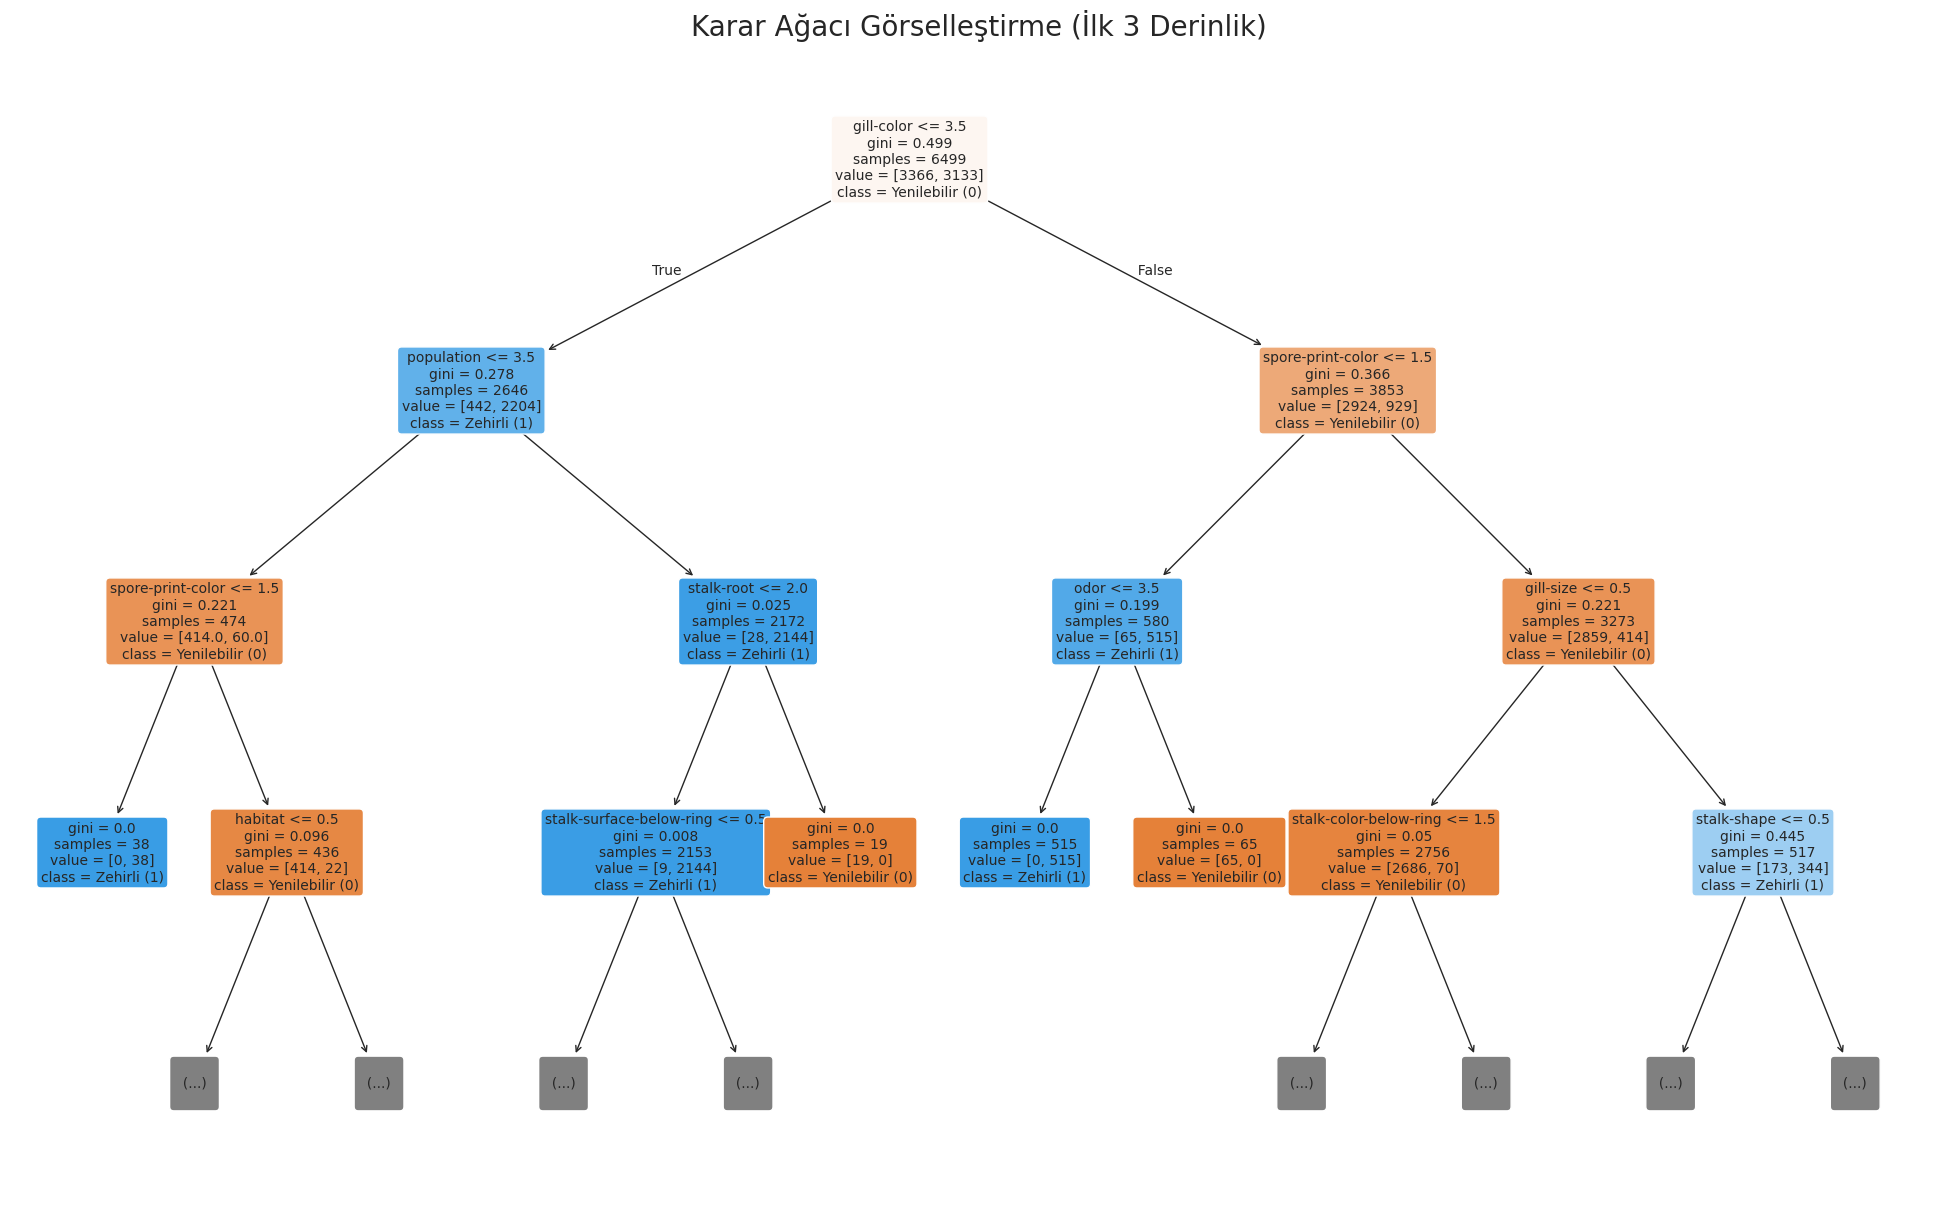

In [12]:
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 15))
plot_tree(model_final,
          feature_names=X.columns.tolist(),  # Özellik isimlerini kullan
          class_names=['Yenilebilir (0)', 'Zehirli (1)'], # Sınıf isimlerini kullan
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3) # Tam ağaç çok büyük olabileceği için ilk birkaç derinliği görselleştiriyoruz
plt.title('Karar Ağacı Görselleştirme (İlk 3 Derinlik)', fontsize=20)
plt.show()

### 4d. Yorum
Görselleştirilen Karar Ağacı'nın **kök düğümünde kullanılan özellik `odor`'dur.** Bu durum, `odor` özelliğinin veri setindeki en yüksek Bilgi Kazancına (Information Gain) sahip olduğunu ve sınıflandırma için en önemli ayrımı yaptığını göstermektedir. Bilgi Kazancı, bir özelliğin bir düğümdeki entropiyi veya Gini safsızlığını ne kadar azalttığını ölçer. `odor` özelliğini kullanarak, model veri setini en etkili şekilde ikiye böler. İlk keşifsel veri analizimizde `odor` özelliğinin sınıfları çok net ayırdığı gözlemlenmişti, bu da `plot_tree()` görselleştirmesinde kök düğümde yer almasıyla örtüşmektedir. `odor` özelliğindeki belirli değerler, mantarların zehirli veya yenilebilir olup olmadığını yüksek doğrulukla belirlemeye olanak tanır.